In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (300).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (391).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (452).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (89).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (238).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (262).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (343).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (388).json
/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion/Hard/Labels/Pascal VOC/H (91).json
/kaggle/input/dataset

# Install Dependencies

In [38]:
!pip install -q albumentations segmentation-models-pytorch timm

# SETUP AND CONFIG

In [39]:
import os,glob,json,random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader



In [40]:
DATA_ROOT = "/kaggle/input/datasets/madhvi0911/damage-segmentation/Damage Segmentaion"
TIERS = ["Easy", "Medium", "Hard"]
WORK_DIR = "/kaggle/working"
CLASS_NAMES = ["background", "cracks", "spalling"]
SEG_NUM_CLASSES = len(CLASS_NAMES)  

In [41]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
os.makedirs(WORK_DIR, exist_ok=True)


Using device: cuda


In [42]:
def collect_pairs(data_root, tiers):
    pairs = []
    for tier in tiers:
        img_dir = os.path.join(data_root, tier, "Images")
        lbl_dir = os.path.join(data_root, tier, "Labels", "Pascal VOC")
        img_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) +
                            glob.glob(os.path.join(img_dir, "*.png")))
        for img_path in img_paths:
            stem = os.path.splitext(os.path.basename(img_path))[0]
            json_path = os.path.join(lbl_dir, stem + ".json")
            json_path = json_path if os.path.exists(json_path) else None
            pairs.append((img_path, json_path, tier))
    return pairs


In [43]:
all_pairs = collect_pairs(DATA_ROOT, TIERS)
random.shuffle(all_pairs)
by_tier = {t: [p for p in all_pairs if p[2] == t] for t in TIERS}


In [44]:
train_pairs, val_pairs, test_pairs = [], [], []
for t, plist in by_tier.items():
    n = len(plist)
    n_train = int(0.70 * n)
    n_val = int(0.15 * n)
    train_pairs += plist[:n_train]
    val_pairs   += plist[n_train:n_train + n_val]
    test_pairs  += plist[n_train + n_val:]

random.shuffle(train_pairs); random.shuffle(val_pairs); random.shuffle(test_pairs)
print(f"Total: {len(all_pairs)} | Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")
for t in TIERS:
    print(f"  {t}: total={len(by_tier[t])}, train={sum(1 for p in train_pairs if p[2]==t)}, "
          f"val={sum(1 for p in val_pairs if p[2]==t)}, test={sum(1 for p in test_pairs if p[2]==t)}")


Total: 1500 | Train: 1050 | Val: 225 | Test: 225
  Easy: total=500, train=350, val=75, test=75
  Medium: total=500, train=350, val=75, test=75
  Hard: total=500, train=350, val=75, test=75


In [45]:
def load_annotations(json_path):
    if json_path is None:
        return None, None, []
    with open(json_path) as f:
        d = json.load(f)
    return d["image"]["width"], d["image"]["height"], d.get("annotations", [])



In [46]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def rasterize_mask(img_w, img_h, annotations):
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    for ann in annotations:
        cid = ann["category_id"]
        for poly in ann.get("segmentation", []):
            pts = np.array(poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [pts], color=int(cid) + 1)
    return mask

IMG_SIZE = 576
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

In [47]:
class DamSegDataset(Dataset):
    def __init__(self, pairs, img_size=IMG_SIZE, augment=True):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment
        if augment:
            self.tf = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.RandomRotate90(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                                    rotate_limit=15, p=0.4, border_mode=cv2.BORDER_CONSTANT),
                A.RandomBrightnessContrast(p=0.3),
                A.OneOf([A.GaussNoise(p=1.0), A.GaussianBlur(p=1.0)], p=0.2),
                A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.15),
                A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                ToTensorV2(),
            ])
        else:
            self.tf = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
                ToTensorV2(),
            ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, json_path, tier = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        img_h, img_w = image.shape[:2]
        json_w, json_h, annotations = load_annotations(json_path)
        mask = rasterize_mask(json_w or img_w, json_h or img_h, annotations)
        if mask.shape[:2] != (img_h, img_w):
            mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)
        augmented = self.tf(image=image, mask=mask)
        return augmented["image"], augmented["mask"].long()

BATCH_SIZE = 8
train_ds = DamSegDataset(train_pairs, augment=True)
val_ds   = DamSegDataset(val_pairs,   augment=False)
test_ds  = DamSegDataset(test_pairs,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 1050 | Val: 225 | Test: 225


/tmp/ipykernel_58/1038088911.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.15),


In [48]:
import segmentation_models_pytorch as smp

seg_model = smp.Segformer(
    encoder_name="mit_b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=SEG_NUM_CLASSES,
).to(device)

print(seg_model.__class__.__name__, "loaded with encoder mit_b2 -> classes:", SEG_NUM_CLASSES)
n_params = sum(p.numel() for p in seg_model.parameters())
print(f"Total params: {n_params/1e6:.2f}M")

Segformer loaded with encoder mit_b2 -> classes: 3
Total params: 24.72M


In [49]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets, num_classes):
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        cardinality = torch.sum(probs + targets_onehot, dims)
        dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)
        return 1 - dice.mean()

In [50]:
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1.0):
        super().__init__()
        self.alpha, self.beta, self.smooth = alpha, beta, smooth
    def forward(self, logits, targets, num_classes):
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        tp = torch.sum(probs * targets_onehot, dims)
        fp = torch.sum(probs * (1 - targets_onehot), dims)
        fn = torch.sum((1 - probs) * targets_onehot, dims)
        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return 1 - tversky.mean()

In [51]:
class CEDiceTverskyLoss(nn.Module):
    def __init__(self, num_classes, ce_w=0.3, dice_w=0.4, tversky_w=0.3):
        super().__init__()
        self.num_classes = num_classes
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.tversky = TverskyLoss(alpha=0.3, beta=0.7)
        self.ce_w, self.dice_w, self.tversky_w = ce_w, dice_w, tversky_w
    def forward(self, logits, targets):
        return (self.ce_w * self.ce(logits, targets) +
                self.dice_w * self.dice(logits, targets, self.num_classes) +
                self.tversky_w * self.tversky(logits, targets, self.num_classes))

criterion = CEDiceTverskyLoss(SEG_NUM_CLASSES)

In [52]:
def compute_confusion_matrix(preds, targets, num_classes):
    mask = (targets >= 0) & (targets < num_classes)
    idx = num_classes * targets[mask].long() + preds[mask].long()
    return torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes).float()

def metrics_from_confmat(confmat):
    tp = torch.diag(confmat)
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    iou = tp / (tp + fp + fn + 1e-10)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-10)
    pixel_acc = tp.sum() / confmat.sum()
    return {
        "mean_iou": iou.mean().item(), "per_class_iou": iou.tolist(),
        "mean_dice": dice.mean().item(), "per_class_dice": dice.tolist(),
        "pixel_accuracy": pixel_acc.item(),
    }

@torch.no_grad()
def tta_predict(model, images):
    logits = model(images)
    probs = F.softmax(logits, dim=1)
    flipped = torch.flip(images, dims=[3])
    probs += torch.flip(F.softmax(model(flipped), dim=1), dims=[3])
    flipped_v = torch.flip(images, dims=[2])
    probs += torch.flip(F.softmax(model(flipped_v), dim=1), dims=[2])
    return probs / 3.0

@torch.no_grad()
def evaluate(model, loader, num_classes, use_tta=False):
    model.eval()
    confmat = torch.zeros(num_classes, num_classes)
    total_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        if use_tta:
            probs = tta_predict(model, images)
            preds = probs.argmax(1)
            loss = F.nll_loss(torch.log(probs + 1e-10), masks)
        else:
            out = model(images)
            loss = criterion(out, masks)
            preds = out.argmax(1)
        total_loss += loss.item() * images.size(0)
        confmat += compute_confusion_matrix(preds.cpu(), masks.cpu(), num_classes)
    metrics = metrics_from_confmat(confmat)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics

/tmp/ipykernel_58/2802915028.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_58/2802915028.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/100 | train_loss=0.6505 | val_loss=0.4780 | val_mIoU=0.5619 | val_pixel_acc=0.9364
  -> New best mIoU 0.5619, checkpoint saved.
Epoch 002/100 | train_loss=0.3842 | val_loss=0.2737 | val_mIoU=0.6919 | val_pixel_acc=0.9655
  -> New best mIoU 0.6919, checkpoint saved.
Epoch 003/100 | train_loss=0.2998 | val_loss=0.2534 | val_mIoU=0.6654 | val_pixel_acc=0.9648
  -> No improvement for 1/15 epochs
Epoch 004/100 | train_loss=0.2787 | val_loss=0.2147 | val_mIoU=0.7301 | val_pixel_acc=0.9696
  -> New best mIoU 0.7301, checkpoint saved.
Epoch 005/100 | train_loss=0.2507 | val_loss=0.2134 | val_mIoU=0.7317 | val_pixel_acc=0.9697
  -> New best mIoU 0.7317, checkpoint saved.
Epoch 006/100 | train_loss=0.2262 | val_loss=0.2090 | val_mIoU=0.7109 | val_pixel_acc=0.9703
  -> No improvement for 1/15 epochs
Epoch 007/100 | train_loss=0.2179 | val_loss=0.1918 | val_mIoU=0.7323 | val_pixel_acc=0.9719
  -> New best mIoU 0.7323, checkpoint saved.
Epoch 008/100 | train_loss=0.2230 | val_loss=0.2191 

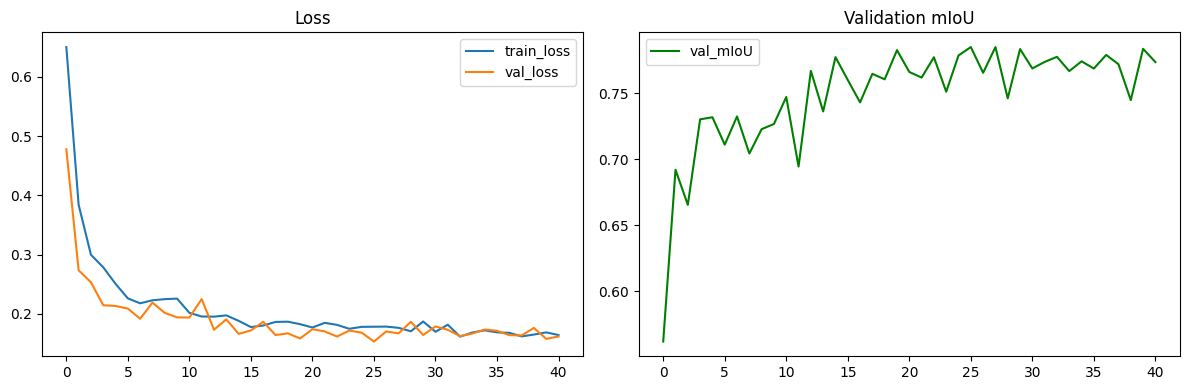

In [53]:
EPOCHS = 100
LR = 6e-5
PATIENCE = 15   # stop if val mIoU doesn't improve for 15 straight epochs

optimizer = torch.optim.AdamW(seg_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

best_miou = 0.0
epochs_without_improvement = 0
history = {"train_loss": [], "val_loss": [], "val_miou": []}
CKPT_PATH = os.path.join(WORK_DIR, "segformer_best.pth")

for epoch in range(1, EPOCHS + 1):
    seg_model.train()
    running_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out = seg_model(images)
            loss = criterion(out, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_ds)
    scheduler.step()
    val_metrics = evaluate(seg_model, val_loader, SEG_NUM_CLASSES, use_tta=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_miou"].append(val_metrics["mean_iou"])

    print(f"Epoch {epoch:03d}/{EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | val_mIoU={val_metrics['mean_iou']:.4f} | "
          f"val_pixel_acc={val_metrics['pixel_accuracy']:.4f}")

    if val_metrics["mean_iou"] > best_miou:
        best_miou = val_metrics["mean_iou"]
        epochs_without_improvement = 0
        torch.save(seg_model.state_dict(), CKPT_PATH)
        print(f"  -> New best mIoU {best_miou:.4f}, checkpoint saved.")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement for {epochs_without_improvement}/{PATIENCE} epochs")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val mIoU: {best_miou:.4f}")
        break

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["val_miou"], label="val_mIoU", color="green")
axes[1].set_title("Validation mIoU"); axes[1].legend()
plt.tight_layout(); plt.show()


In [54]:
seg_model.load_state_dict(torch.load(CKPT_PATH))
test_metrics = evaluate(seg_model, test_loader, SEG_NUM_CLASSES, use_tta=True)

print("===== TEST SET RESULTS (TTA: hflip+vflip avg) =====")
print(f"Mean IoU:        {test_metrics['mean_iou']:.4f}")
print(f"Mean Dice:       {test_metrics['mean_dice']:.4f}")
print(f"Pixel Accuracy:  {test_metrics['pixel_accuracy']:.4f}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<12} IoU={test_metrics['per_class_iou'][i]:.4f}  "
          f"Dice={test_metrics['per_class_dice'][i]:.4f}")


===== TEST SET RESULTS (TTA: hflip+vflip avg) =====
Mean IoU:        0.7395
Mean Dice:       0.8376
Pixel Accuracy:  0.9751
  background   IoU=0.9745  Dice=0.9871
  cracks       IoU=0.5283  Dice=0.6914
  spalling     IoU=0.7158  Dice=0.8344


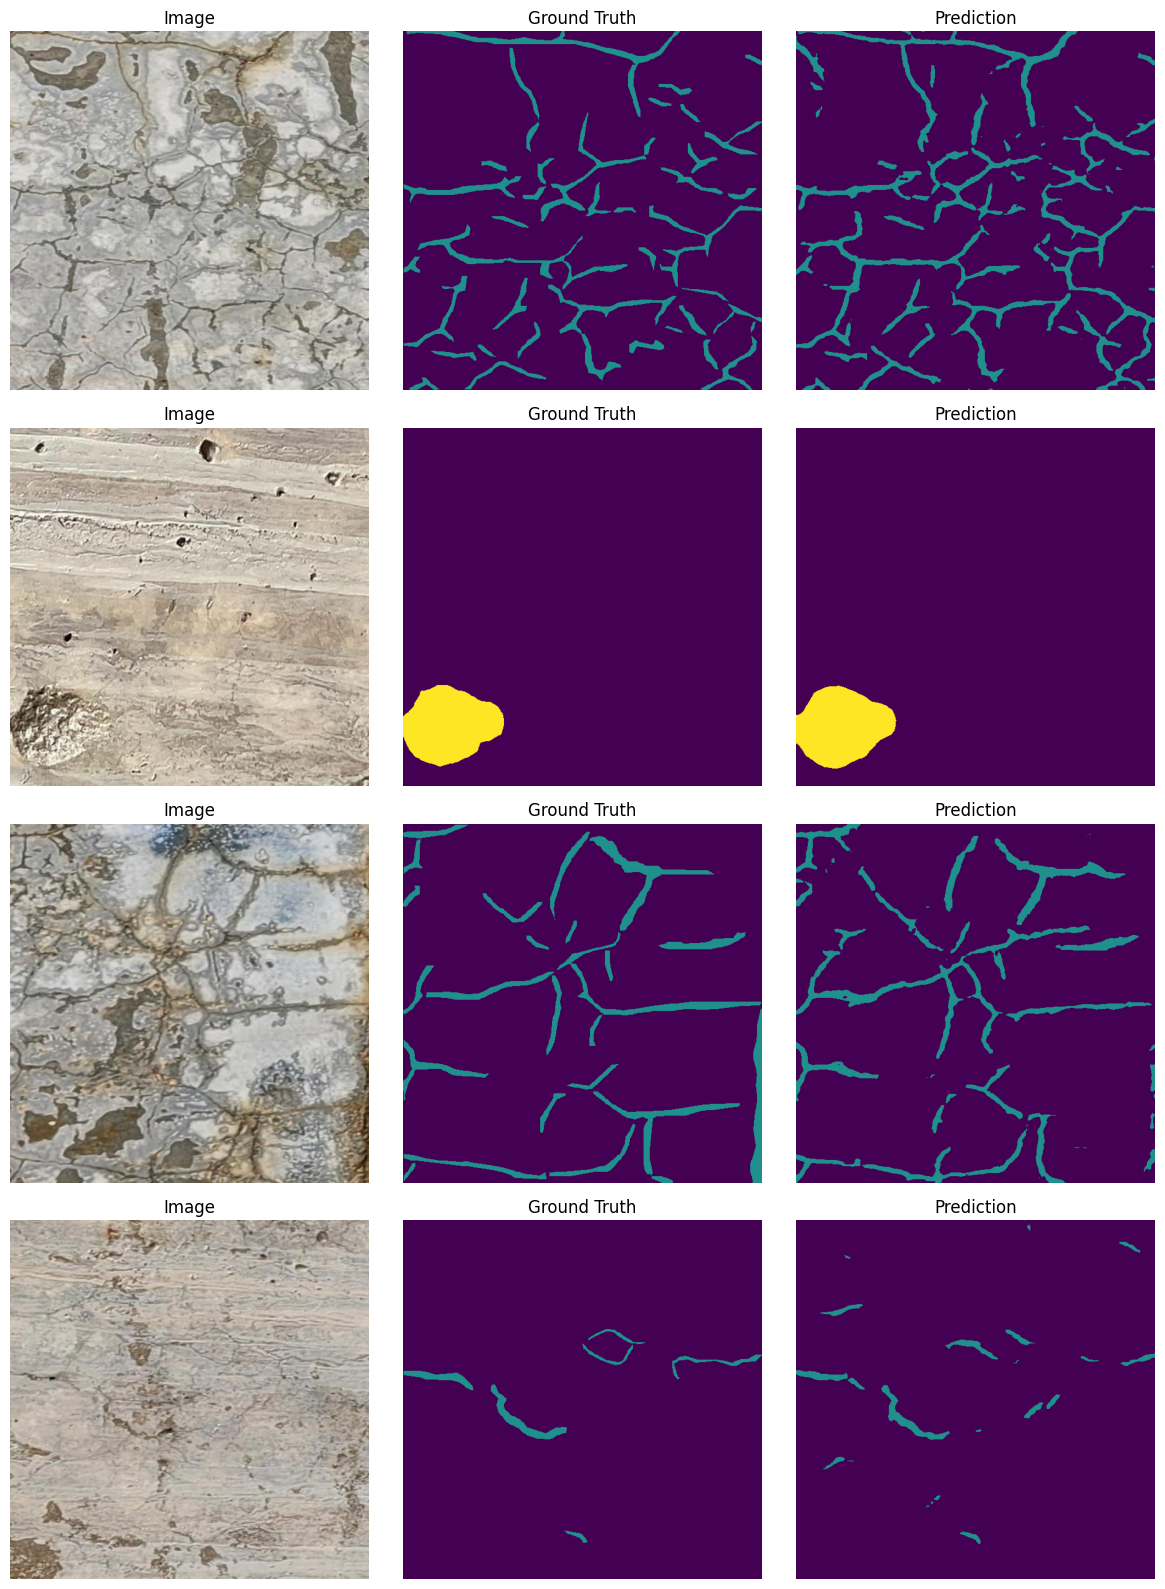

In [55]:
@torch.no_grad()
def visualize_predictions(model, dataset, n=4):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    idxs = random.sample(range(len(dataset)), n)
    mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)
    for row, idx in enumerate(idxs):
        image, mask = dataset[idx]
        probs = tta_predict(model, image.unsqueeze(0).to(device))
        pred = probs.argmax(1).squeeze(0).cpu().numpy()
        img_np = np.clip(image.permute(1, 2, 0).numpy() * std + mean, 0, 1)
        axes[row, 0].imshow(img_np); axes[row, 0].set_title("Image"); axes[row, 0].axis("off")
        axes[row, 1].imshow(mask.numpy(), cmap="viridis", vmin=0, vmax=SEG_NUM_CLASSES-1)
        axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred, cmap="viridis", vmin=0, vmax=SEG_NUM_CLASSES-1)
        axes[row, 2].set_title("Prediction"); axes[row, 2].axis("off")
    plt.tight_layout(); plt.show()

visualize_predictions(seg_model, test_ds, n=4)

In [56]:
print("\n\n===== SEGMENTATION: Per-Tier Test Set Evaluation (with TTA) =====\n")
seg_tier_results = []

for tier_name in TIERS:
    tier_test_pairs = [p for p in test_pairs if p[2] == tier_name]
    if len(tier_test_pairs) == 0:
        print(f"{tier_name}: no test images found, skipping.")
        continue
    tier_test_ds = DamSegDataset(tier_test_pairs, augment=False)
    tier_test_loader = DataLoader(tier_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                   num_workers=2, pin_memory=True)
    metrics = evaluate(seg_model, tier_test_loader, SEG_NUM_CLASSES, use_tta=True)

    result = {
        "tier": tier_name, "n_images": len(tier_test_pairs),
        "mean_iou": metrics["mean_iou"], "mean_dice": metrics["mean_dice"],
        "pixel_accuracy": metrics["pixel_accuracy"],
        "background_iou": metrics["per_class_iou"][0],
        "cracks_iou": metrics["per_class_iou"][1],
        "spalling_iou": metrics["per_class_iou"][2],
    }
    seg_tier_results.append(result)
    print(f"--- {tier_name} tier ({result['n_images']} test images) ---")
    print(f"  Mean IoU={result['mean_iou']:.4f} | Mean Dice={result['mean_dice']:.4f} | "
          f"Pixel Acc={result['pixel_accuracy']:.4f}")
    print(f"  BG IoU={result['background_iou']:.4f} | Cracks IoU={result['cracks_iou']:.4f} | "
          f"Spalling IoU={result['spalling_iou']:.4f}\n")

print("\n===== SUMMARY: Segmentation Performance by Difficulty Tier =====")
print(f"{'Tier':<10}{'N':<6}{'MeanIoU':<10}{'MeanDice':<10}{'BG IoU':<10}{'Cracks IoU':<12}{'Spalling IoU':<12}")
for r in seg_tier_results:
    print(f"{r['tier']:<10}{r['n_images']:<6}{r['mean_iou']:<10.4f}{r['mean_dice']:<10.4f}"
          f"{r['background_iou']:<10.4f}{r['cracks_iou']:<12.4f}{r['spalling_iou']:<12.4f}")




===== SEGMENTATION: Per-Tier Test Set Evaluation (with TTA) =====

--- Easy tier (75 test images) ---
  Mean IoU=0.7553 | Mean Dice=0.8501 | Pixel Acc=0.9843
  BG IoU=0.9843 | Cracks IoU=0.5755 | Spalling IoU=0.7061

--- Medium tier (75 test images) ---
  Mean IoU=0.7793 | Mean Dice=0.8658 | Pixel Acc=0.9794
  BG IoU=0.9790 | Cracks IoU=0.5691 | Spalling IoU=0.7899

--- Hard tier (75 test images) ---
  Mean IoU=0.6978 | Mean Dice=0.8064 | Pixel Acc=0.9616
  BG IoU=0.9601 | Cracks IoU=0.4840 | Spalling IoU=0.6493


===== SUMMARY: Segmentation Performance by Difficulty Tier =====
Tier      N     MeanIoU   MeanDice  BG IoU    Cracks IoU  Spalling IoU
Easy      75    0.7553    0.8501    0.9843    0.5755      0.7061      
Medium    75    0.7793    0.8658    0.9790    0.5691      0.7899      
Hard      75    0.6978    0.8064    0.9601    0.4840      0.6493      
